# Análise Exploratória sobre Fatores Associados ao Tratamento de Saúde Mental em Jovens

## 1. DEFINIÇÃO DO PROBLEMA

### Definição do Problema

A saúde mental tem se tornado um tema cada vez mais relevante, especialmente entre jovens e adultos. Este trabalho tem como objetivo analisar fatores que influenciam a busca por tratamento de saúde mental, utilizando dados de uma pesquisa realizada com profissionais da área de tecnologia.

O foco será identificar padrões e relações entre variáveis como idade, gênero, ambiente de trabalho e histórico familiar com a decisão de buscar tratamento.

Trata-se de um problema de aprendizado supervisionado, com foco em análise exploratória de dados.

Premissas:
- A variável "treatment" indica se o indivíduo já buscou tratamento.
- A idade será utilizada para filtrar o público jovem.

Restrição:
- O dataset não representa toda a população, sendo limitado ao contexto da área de tecnologia.

## 2. IMPORTAÇÃO E LEITURA DOS DADOS

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Configuração visual
sns.set(style="whitegrid")

# Download do dataset
path = kagglehub.dataset_download("osmi/mental-health-in-tech-survey")

# Verificar arquivos disponíveis
print("Arquivos no diretório:", os.listdir(path))

# Selecionar automaticamente o arquivo CSV
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

# Carregar os dados
df = pd.read_csv(f"{path}/{csv_file}")

# Visualizar primeiras linhas
df.head()

Arquivos no diretório: ['survey.csv']


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Importação e Leitura dos Dados

Os dados foram obtidos a partir da plataforma Kaggle, utilizando a biblioteca kagglehub para download automatizado.

Após o download, foi realizada a verificação dos arquivos disponíveis no diretório e a seleção automática do arquivo no formato CSV.

Em seguida, os dados foram carregados utilizando a biblioteca pandas, permitindo a visualização inicial das primeiras linhas do dataset.

### 2. 1 TRADUÇÃO DO DF PARA PORTUGUÊS

In [229]:
# Tradução das Colunas
df.rename(columns={
    'Timestamp': 'Data',
    'Age': 'Idade',
    'Gender': 'Gênero',
    'Country': 'País',
    'state': 'Estado',
    'self_employed': 'Autonomo',
    'family_history': 'Histórico Familiar',
    'treatment': 'Tratamento',
    'work_interfere': 'Interferência no Trabalho',
    'no_employees': 'Número de Funcionários',
    'remote_work': 'Trabalho Remoto',
    'tech_company': 'Empresa de Tecnologia',
    'benefits': 'Benefícios',
    'care_options': 'Opções de Cuidado',
    'wellness_program': 'Programa de Bem-Estar',
    'seek_help': 'Busca por Ajuda',
    'anonymity': 'Anonimato',
    'leave': 'Licença',
    'mental_health_consequence': 'Consquencia Saúde Mental',
    'phys_health_consequence': 'consequencia Saúde Física',
    'coworkers': 'Colegas',
    'supervisor': 'Supervisor',
    'mental_health_interview': 'Entrevista Saúde Mental',
    'phys_health_interview': 'Entrevista Saúde Física',
    'mental_vs_physical': 'Mental vs Físico',
    'obs_consequence': 'Observações sobre as Consequências'
}, inplace=True)

#Tradução das Linhas S/N

df['Tratamento'] = df['Tratamento'].map({'Yes': 'Sim', 'No': 'Não'})
df['Histórico Familiar'] = df['Histórico Familiar'].map({'Yes': 'Sim', 'No': 'Não'})
df['Trabalho Remoto'] = df['Trabalho Remoto'].map({'Yes': 'Sim', 'No': 'Não'})
df['Empresa de Tecnologia'] = df['Empresa de Tecnologia'].map({'Yes': 'Sim', 'No': 'Não'})
df['Benefícios'] = df['Benefícios'].map({'Yes': 'Sim', 'No': 'Não'})

#Tradução coluna "Interferência no Trabalho"
df['Interferência no Trabalho'] = df['Interferência no Trabalho'].map({
            'Never': 'Nunca',   
            'Rarely': 'Raramente',
            'Sometimes': 'Às vezes',
            'Often': 'Frequentemente',
            'NA': 'Não se Aplica'
        })



#Tradução das colunas gênero

df['Gênero'] = df['Gênero'].str.lower().str.strip()

df['Gênero'] = df['Gênero'].replace({
    'male': 'Masculino',
    'm': 'Masculino',
    'female': 'Feminino',
    'f': 'Feminino'
})

# Outros valores viram "Outros"
df['Gênero'] = df['Gênero'].apply(
    lambda x: x if x in ['Masculino', 'Feminino'] else 'Outros'
)

### 2. 2 TRATAMENTO INICIAL

In [230]:
# Limpeza de dados
df = df[(df['Idade'] <= 80) & (df['Idade'] >= 0)]

# Remover colunas irrelevantes
df.drop(columns=['comments'], inplace=True)

# Converter a coluna de data para o formato datetime
df['Data'] = pd.to_datetime(df['Data']).dt.date

## 3. ANÁLISE INICIAL

In [231]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1254 entries, 0 to 1258
Data columns (total 26 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Data                                1254 non-null   object
 1   Idade                               1254 non-null   int64 
 2   Gênero                              1254 non-null   object
 3   País                                1254 non-null   object
 4   Estado                              741 non-null    object
 5   Autonomo                            1236 non-null   object
 6   Histórico Familiar                  1254 non-null   object
 7   Tratamento                          1254 non-null   object
 8   Interferência no Trabalho           991 non-null    object
 9   Número de Funcionários              1254 non-null   object
 10  Trabalho Remoto                     1254 non-null   object
 11  Empresa de Tecnologia               1254 non-null   object
 1

Data                                    0
Idade                                   0
Gênero                                  0
País                                    0
Estado                                513
Autonomo                               18
Histórico Familiar                      0
Tratamento                              0
Interferência no Trabalho             263
Número de Funcionários                  0
Trabalho Remoto                         0
Empresa de Tecnologia                   0
Benefícios                            408
Opções de Cuidado                       0
Programa de Bem-Estar                   0
Busca por Ajuda                         0
Anonimato                               0
Licença                                 0
Consquencia Saúde Mental                0
consequencia Saúde Física               0
Colegas                                 0
Supervisor                              0
Entrevista Saúde Mental                 0
Entrevista Saúde Física           

O dataset possui diversas variáveis categóricas e numéricas.
Observa-se a presença de valores ausentes, especialmente em variáveis relacionadas ao ambiente de trabalho.

Esses dados precisarão ser tratados na etapa de pré-processamento.

## 4. FILTRO POR IDADE

In [232]:
# Filtrar jovens (até 25 anos)
df_jovens = df[df['Idade'] <= 25]

df_jovens.shape

(220, 26)

In [233]:
# Filtrar adultos (26 a 60 anos)
df_adultos = df[(df['Idade'] > 25) & (df['Idade'] < 60)]

df_adultos.shape

(1028, 26)

In [234]:
# Filtrar idosos (acima de 60 anos)
df_idosos = df[df['Idade'] >= 60]

df_idosos.shape

(6, 26)

## 5. DISTRIBUIÇÃO DE IDADE

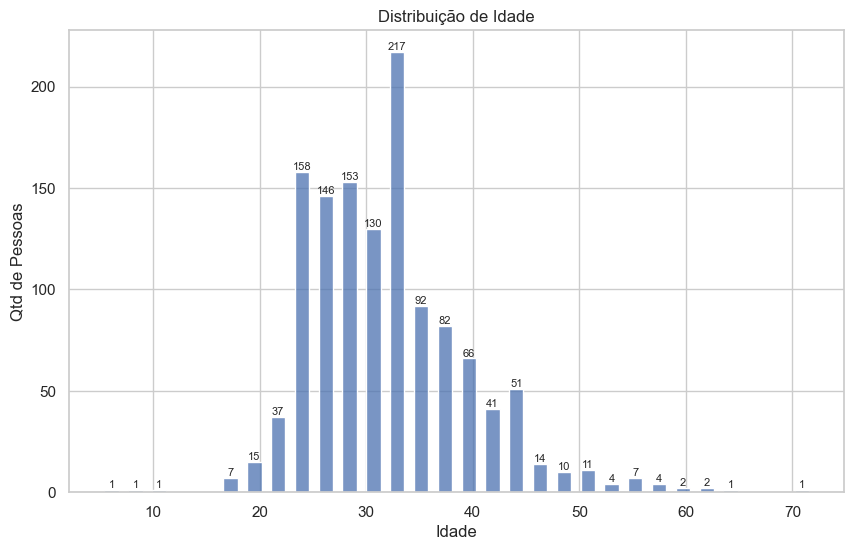

In [235]:
plt.figure(figsize=(10,6))
ax = sns.histplot(df['Idade'], bins=30, shrink=0.6)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.title('Distribuição de Idade')
plt.ylabel('Qtd de Pessoas')
plt.show()

Observa-se que a maioria dos respondentes está concentrada entre 20 e 35 anos.
Há presença de valores extremos, indicando possíveis outliers que podem impactar a análise.

## 6.TRATAMENTO

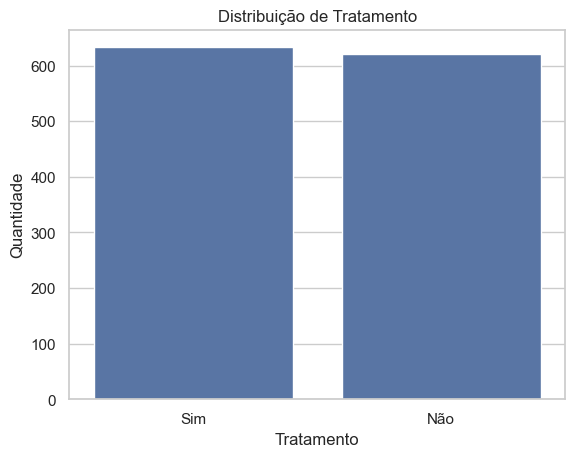

In [236]:
sns.countplot(x='Tratamento', data=df)
plt.title('Distribuição de Tratamento')
plt.ylabel('Quantidade')
plt.xlabel('Tratamento')
plt.show()

A variável de tratamento apresenta distribuição relativamente equilibrada, permitindo análises sem necessidade imediata de balanceamento.

## 7.IDADE vs TRATAMENTO

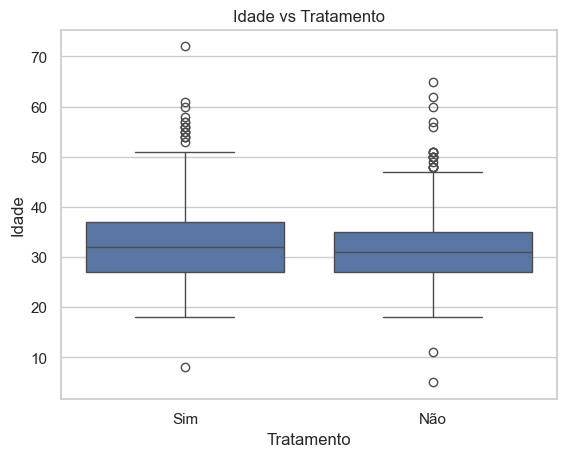

In [237]:
sns.boxplot(x='Tratamento', y='Idade', data=df)
plt.title('Idade vs Tratamento')
plt.ylabel('Idade')
plt.xlabel('Tratamento')
plt.show()

Indivíduos que buscaram tratamento apresentam uma leve variação na distribuição de idade, sugerindo possíveis diferenças comportamentais entre grupos.

## 8.GENERO vs TRATAMENTO

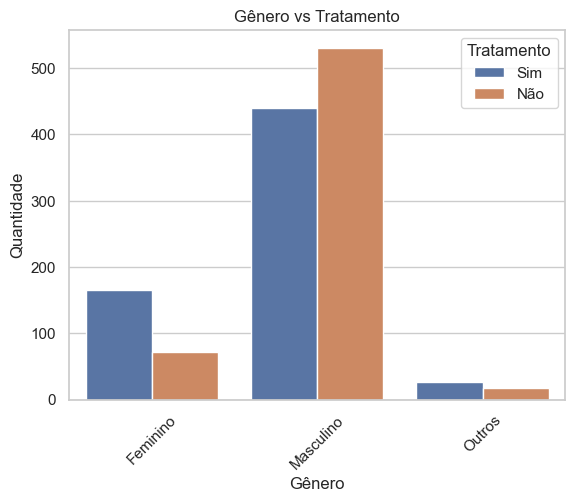

In [238]:
sns.countplot(x='Gênero', hue='Tratamento', data=df)
plt.xticks(rotation=45)
plt.title('Gênero vs Tratamento')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

Observa-se diferença na proporção de busca por tratamento entre os gêneros, o que pode indicar fatores sociais ou culturais envolvidos.

### COMPARAR JOVENS vs ADULTOS

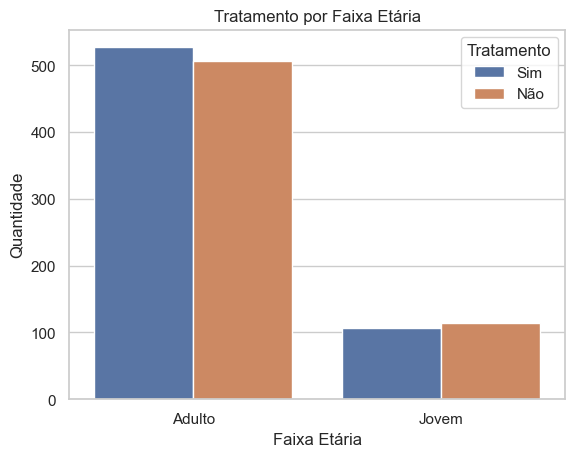

In [239]:
df['Faixa Etária'] = df['Idade'].apply(lambda x: 'Jovem' if x <= 25 else 'Adulto')

sns.countplot(x='Faixa Etária', hue='Tratamento', data=df)
plt.title('Tratamento por Faixa Etária')
plt.ylabel('Quantidade')
plt.show()

Observa-se diferença no comportamento entre jovens e adultos em relação à busca por tratamento. 
Isso sugere que fatores como maturidade, acesso à informação ou estigma podem influenciar essa decisão.

### HISTÓRICO FAMILIAR

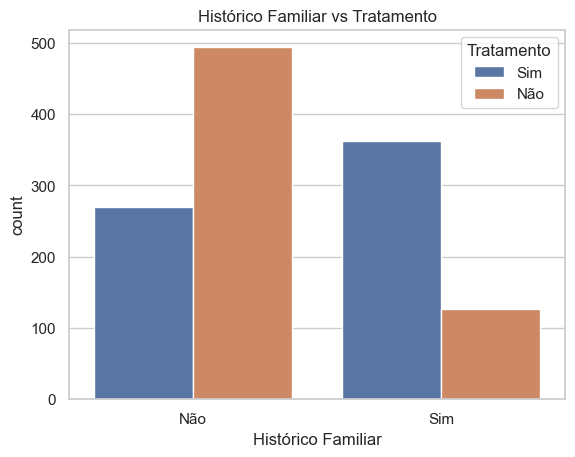

In [240]:
sns.countplot(x='Histórico Familiar', hue='Tratamento', data=df)
plt.title('Histórico Familiar vs Tratamento')
plt.show()

Indivíduos com histórico familiar apresentam maior propensão a buscar tratamento, indicando possível influência genética ou maior conscientização sobre saúde mental.

### AMBIENTE DE TRABALHO

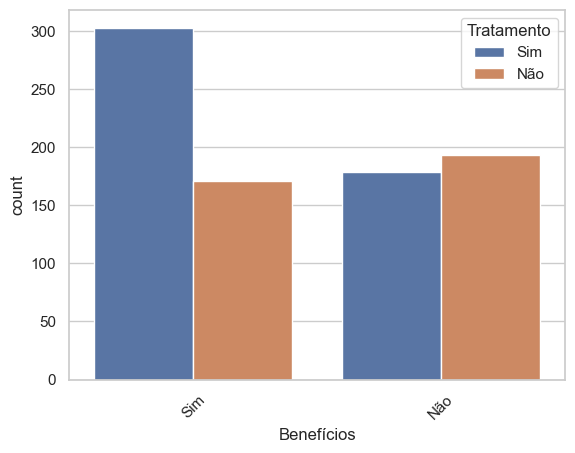

In [241]:
sns.countplot(x='Benefícios', hue='Tratamento', data=df)
plt.xticks(rotation=45)
plt.show()

A presença de benefícios relacionados à saúde mental parece influenciar positivamente a busca por tratamento, sugerindo que políticas organizacionais têm impacto relevante.

### INTERFERÊNCIA NO TRABALHO

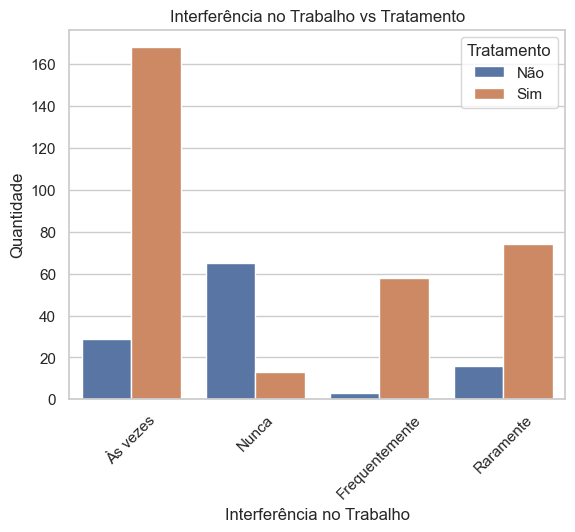

In [246]:
sns.countplot(x='Interferência no Trabalho', hue='Tratamento', data=df)
plt.xticks(rotation=45)
plt.title('Interferência no Trabalho vs Tratamento')
plt.ylabel('Quantidade')
plt.show()

Indivíduos que relatam interferência da saúde mental no trabalho tendem a buscar mais tratamento, indicando que o impacto funcional pode ser um fator determinante.

### Taxa de tratamento

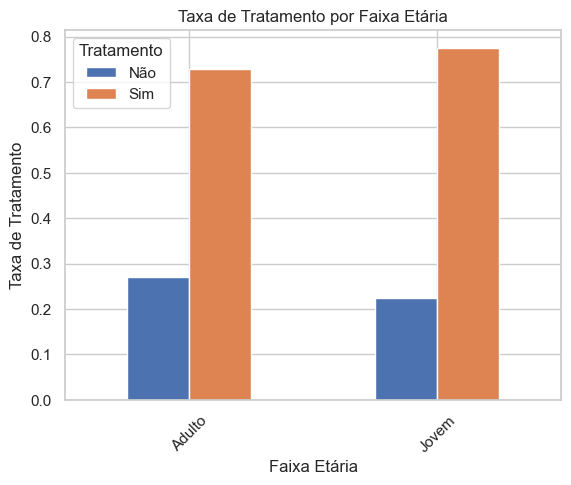

In [249]:
taxa = df.groupby('Faixa Etária')['Tratamento'].value_counts(normalize=True).unstack()
taxa.plot(kind='bar')
plt.title('Taxa de Tratamento por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Tratamento')
plt.xticks(rotation=45)
plt.show()

## 9. PRÉ-PROCESSAMENTO
### Tratar valores faltantes

In [243]:
df = df.dropna()

### Converter variáveis

In [244]:
df['tratamento'] = df['tratamento'].map({'Yes': 1, 'No': 0})

KeyError: 'tratamento'

### One-hot encoding

In [ ]:
df = pd.get_dummies(df, drop_first=True)

Foram removidos valores nulos para garantir consistência dos dados.
A variável alvo foi convertida para formato numérico e variáveis categóricas foram transformadas utilizando one-hot encoding.

## 10. MATRIZ DE CORRELAÇÃO

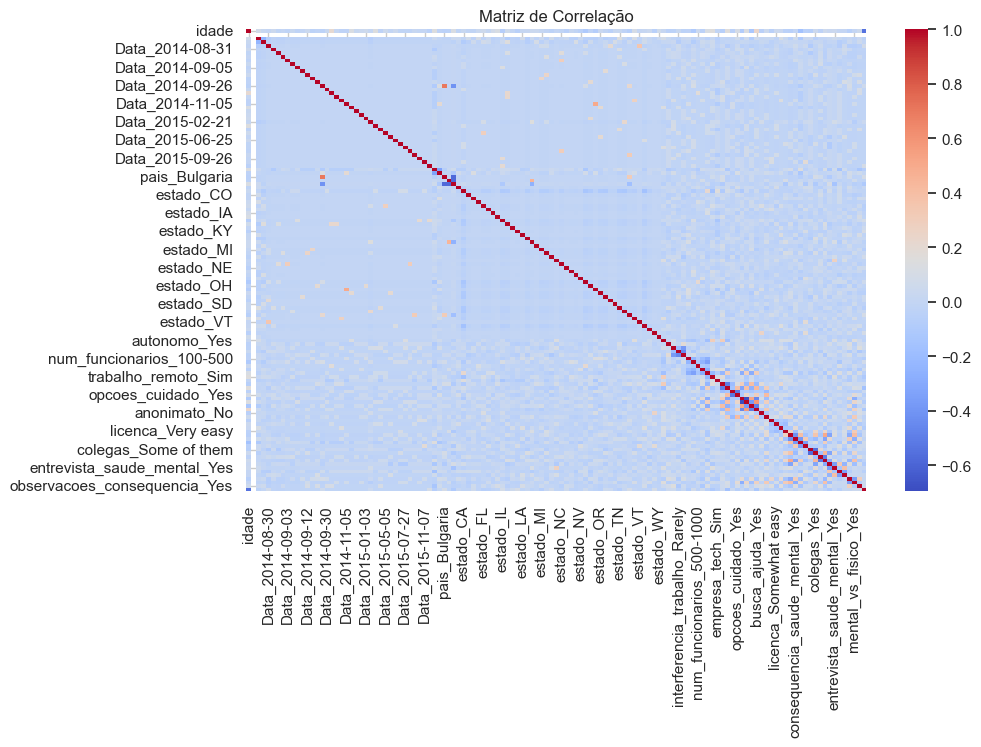

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm'
            #, annot=True, fmt=".2f"
            )
plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação permite identificar relações entre variáveis, destacando possíveis fatores associados à busca por tratamento.

## 11. CONCLUSÃO

A análise indicou que fatores como idade, gênero e ambiente de trabalho possuem relação com a busca por tratamento de saúde mental.

Além disso, foi possível observar padrões que sugerem a influência de aspectos sociais e culturais nesse comportamento.

Como trabalhos futuros, recomenda-se a aplicação de modelos preditivos para aprofundar a análise.